# Utilizing the SensorThings API
## Preliminary Steps

Replace `IST_SOS_ENDPOINT` in the following script with your istSOS base URL (http://api:5000/v4/v1.1 or https://istsos.org/v4/v1.1).

In [2]:
import json
import requests

from IPython.display import Markdown, display

from istsos_utils import (
    REQUEST_TIMEOUT,
    auth_headers,
    build_bulk_observations,
    build_column_to_datastream_id,
    display_error_response,
    display_json,
    get_datastreams_for_thing,
    get_network_id_by_name,
    get_observations,
    login,
    post_bulk_observations,
    preview_bulk_observations,
    print_created,
    read_observations_csv,
    result_to_float,
)

IST_SOS_ENDPOINT = "http://api:5000/v4/v1.1"

## Step 1 — Login as editor

From now on, we use an `editor` user.

The `editor` role is allowed to create and manage the SensorThings entities used in this example.

The username is also used as a prefix for the names of the resources created in the notebook. This avoids name collisions when multiple people run the workshop at the same time.

In [3]:
username = input("Enter your username: ")
password = input("Enter your password: ")

if not username or not password:
    print("Username or password is empty")

else:
    token, login_body = login(
        IST_SOS_ENDPOINT,
        username,
        password,
        timeout=REQUEST_TIMEOUT,
    )

    if token:
        prefix = username + "-"
        print("Logged in as editor")
        print("Your station name will be prefixed with: " + prefix)


Enter your username:  group1_editor
Enter your password:  qwertz


Logged in as editor
Your station name will be prefixed with: group1_editor-


In [4]:
network_name = "DDT_workshop"

network_id = get_network_id_by_name(
    IST_SOS_ENDPOINT,
    token,
    network_name,
    timeout=REQUEST_TIMEOUT,
)

print(f"Network ID: {network_id}")

Network ID: 1


### Create Datastreams

In [5]:
body = {
    "name": f"{prefix}ZURICH_PLATFORM",
    "description": "Zurich meteorological platform",
    "properties": {
        "keywords": "temperature,relative_humidity,precipitation,meteo,zurich",
        "description": "Meteorological measurements at Zurich platform"
    },
    "Locations": [
        {
            "name": f"{prefix}ZURICH_PLATFORM_LOCATION",
            "description": "Zurich platform location",
            "encodingType": "application/vnd.geo+json",
            "location": {
                "type": "Point",
                "coordinates": [
                    2682216.85,
                    1247945.20
                ],
                "crs": {
                    "type": "name",
                    "properties": {
                        "name": "EPSG:2056"
                    }
                }
            }
        }
    ],
    "Datastreams": [
        {
            "name": f"{prefix}TEMPERATURE_ZURICH_PLATFORM",
            "description": "Air temperature measured at Zurich platform",
            "observationType": "http://www.opengis.net/def/observationType/OGC-OM/2.0/OM_Measurement",
            "unitOfMeasurement": {
                "name": "Degree Celsius",
                "symbol": "°C",
                "definition": "http://www.opengis.net/def/uom/UCUM/0/Cel"
            },
            "properties": {
                "samplingFrequency": "PT10M",
                "acquisitionFrequency": "PT10M",
                "column": "temperature"
            },
            "ObservedProperty": {
                "name": "air:temperature",
                "definition": "urn:ogc:def:parameter:x-istsos:1.0:air:temperature",
                "description": "Air temperature"
            },
            "Sensor": {
                "name": f"{prefix}ZURICH_PLATFORM_TEMPERATURE_SENSOR",
                "description": "Temperature sensor at Zurich platform",
                "encodingType": "application/json",
                "metadata": "{}"
            },
            "Network": {
                "@iot.id": network_id
            }
        },
        {
            "name": f"{prefix}RELATIVE_HUMIDITY_ZURICH_PLATFORM",
            "description": "Relative air humidity measured at Zurich platform",
            "observationType": "http://www.opengis.net/def/observationType/OGC-OM/2.0/OM_Measurement",
            "unitOfMeasurement": {
                "name": "Percent",
                "symbol": "%",
                "definition": "http://www.opengis.net/def/uom/UCUM/0/%25"
            },
            "properties": {
                "samplingFrequency": "PT10M",
                "acquisitionFrequency": "PT10M",
                "column": "relative_humidity"
            },
            "ObservedProperty": {
                "name": "air:relative_humidity",
                "definition": "urn:ogc:def:parameter:x-istsos:1.0:air:relative_humidity",
                "description": "Relative air humidity"
            },
            "Sensor": {
                "name": f"{prefix}ZURICH_PLATFORM_RELATIVE_HUMIDITY_SENSOR",
                "description": "Relative humidity sensor at Zurich platform",
                "encodingType": "application/json",
                "metadata": "{}"
            },
            "Network": {
                "@iot.id": network_id
            }
        },
        {
            "name": f"{prefix}PRECIPITATION_ZURICH_PLATFORM",
            "description": "Precipitation measured at Zurich platform",
            "observationType": "http://www.opengis.net/def/observationType/OGC-OM/2.0/OM_Measurement",
            "unitOfMeasurement": {
                "name": "Millimetre",
                "symbol": "mm",
                "definition": "http://www.opengis.net/def/uom/UCUM/0/mm"
            },
            "properties": {
                "samplingFrequency": "PT10M",
                "acquisitionFrequency": "PT10M",
                "column": "precipitation"
            },
            "ObservedProperty": {
                "name": "precipitation",
                "definition": "urn:ogc:def:parameter:x-istsos:1.0:precipitation",
                "description": "Precipitation"
            },
            "Sensor": {
                "name": f"{prefix}ZURICH_PLATFORM_PRECIPITATION_SENSOR",
                "description": "Precipitation sensor at Zurich platform",
                "encodingType": "application/json",
                "metadata": "{}"
            },
            "Network": {
                "@iot.id": network_id
            }
        }
    ]
}

response = requests.post(
    IST_SOS_ENDPOINT + "/Things",
    json=body,
    headers=auth_headers(
        token,
        "Create Zurich platform Thing with Location and 3 Datastreams",
    ),
    timeout=REQUEST_TIMEOUT,
)

if response.status_code == 201:
    thing_id = print_created("Thing", response)
    print(f"Thing ID: {thing_id}")

else:
    display_error_response(response)
    raise Exception("Thing creation failed")

Thing created successfully (http://localhost:8018/v4/v1.1/Things(4))
Thing ID: 4


## Create Observations

## Create Observations from CSV

The next cells retrieve the Datastream IDs created inside the Zurich Thing, read the CSV, build the `dataArray` payload, and send it to `/BulkObservations`.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import time

from dateutil import parser
from IPython.display import clear_output, display

# Same base endpoint used for /Things.
server_url = IST_SOS_ENDPOINT

# CSV input.
csv_path = "data/observations.csv"
time_column = "phenomenonTime"

# Bulk endpoint.
bulk_observations_url = f"{server_url}/BulkObservations"

### 1. Retrieve the Datastreams created inside the Thing

In [7]:
created_datastreams = get_datastreams_for_thing(
    server_url,
    token,
    thing_id,
    timeout=30,
)

print(f"Retrieved {len(created_datastreams)} Datastreams")
display_json(created_datastreams)

Retrieved 3 Datastreams


```json
[
  {
    "@iot.id": 3,
    "@iot.selfLink": "http://localhost:8018/v4/v1.1/Datastreams(3)",
    "Thing@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(3)/Thing",
    "Sensor@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(3)/Sensor",
    "ObservedProperty@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(3)/ObservedProperty",
    "Observations@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(3)/Observations",
    "Commit@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(3)/Commit(11)",
    "Network@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(3)/Network",
    "name": "group1_editor-TEMPERATURE_ZURICH_PLATFORM",
    "description": "Air temperature measured at Zurich platform",
    "unitOfMeasurement": {
      "name": "Degree Celsius",
      "symbol": "\u00b0C",
      "definition": "http://www.opengis.net/def/uom/UCUM/0/Cel"
    },
    "observationType": "http://www.opengis.net/def/observationType/OGC-OM/2.0/OM_Measurement",
    "observedArea": null,
    "phenomenonTime": null,
    "resultTime": null,
    "properties": {
      "column": "temperature",
      "samplingFrequency": "PT10M",
      "acquisitionFrequency": "PT10M"
    }
  },
  {
    "@iot.id": 4,
    "@iot.selfLink": "http://localhost:8018/v4/v1.1/Datastreams(4)",
    "Thing@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(4)/Thing",
    "Sensor@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(4)/Sensor",
    "ObservedProperty@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(4)/ObservedProperty",
    "Observations@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(4)/Observations",
    "Commit@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(4)/Commit(11)",
    "Network@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(4)/Network",
    "name": "group1_editor-RELATIVE_HUMIDITY_ZURICH_PLATFORM",
    "description": "Relative air humidity measured at Zurich platform",
    "unitOfMeasurement": {
      "name": "Percent",
      "symbol": "%",
      "definition": "http://www.opengis.net/def/uom/UCUM/0/%25"
    },
    "observationType": "http://www.opengis.net/def/observationType/OGC-OM/2.0/OM_Measurement",
    "observedArea": null,
    "phenomenonTime": null,
    "resultTime": null,
    "properties": {
      "column": "relative_humidity",
      "samplingFrequency": "PT10M",
      "acquisitionFrequency": "PT10M"
    }
  },
  {
    "@iot.id": 5,
    "@iot.selfLink": "http://localhost:8018/v4/v1.1/Datastreams(5)",
    "Thing@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(5)/Thing",
    "Sensor@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(5)/Sensor",
    "ObservedProperty@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(5)/ObservedProperty",
    "Observations@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(5)/Observations",
    "Commit@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(5)/Commit(11)",
    "Network@iot.navigationLink": "http://localhost:8018/v4/v1.1/Datastreams(5)/Network",
    "name": "group1_editor-PRECIPITATION_ZURICH_PLATFORM",
    "description": "Precipitation measured at Zurich platform",
    "unitOfMeasurement": {
      "name": "Millimetre",
      "symbol": "mm",
      "definition": "http://www.opengis.net/def/uom/UCUM/0/mm"
    },
    "observationType": "http://www.opengis.net/def/observationType/OGC-OM/2.0/OM_Measurement",
    "observedArea": null,
    "phenomenonTime": null,
    "resultTime": null,
    "properties": {
      "column": "precipitation",
      "samplingFrequency": "PT10M",
      "acquisitionFrequency": "PT10M"
    }
  }
]
```

### 2. Build the CSV column → Datastream ID mapping

In [8]:
# Final map: CSV column -> Datastream @iot.id
column_to_datastream_id = build_column_to_datastream_id(
    body,
    created_datastreams,
)

display_json(column_to_datastream_id)

```json
{
  "temperature": 3,
  "relative_humidity": 4,
  "precipitation": 5
}
```

### 3. Read and validate the CSV

In [9]:
df = read_observations_csv(
    csv_path,
    time_column,
    required_value_columns=column_to_datastream_id.keys(),
)

print("CSV columns:")
print(list(df.columns))

print(f"Rows: {len(df)}")
display(df.head())
display(df.dtypes)

CSV columns:
['phenomenonTime', 'temperature', 'relative_humidity', 'precipitation']
Rows: 288


,phenomenonTime,temperature,relative_humidity,precipitation
0,2026-05-01 00:00:00+00:00,6.32,91.5,0.000
1,2026-05-01 00:10:00+00:00,6.72,91.5,0.021
2,2026-05-01 00:20:00+00:00,6.86,92.8,0.002
3,2026-05-01 00:30:00+00:00,7.52,90.4,0.043
4,2026-05-01 00:40:00+00:00,7.58,88.8,0.000


phenomenonTime       datetime64[us, UTC]
temperature                      float64
relative_humidity                float64
precipitation                    float64
dtype: object

### 4. Normalize timestamps

In [10]:
invalid_timestamps = df[time_column].isna().sum()

print(f"Rows: {len(df)}")
print(f"Invalid timestamps: {invalid_timestamps}")

if invalid_timestamps > 0:
    display(df[df[time_column].isna()].head())

display(df.head())

Rows: 288
Invalid timestamps: 0


,phenomenonTime,temperature,relative_humidity,precipitation
0,2026-05-01 00:00:00+00:00,6.32,91.5,0.000
1,2026-05-01 00:10:00+00:00,6.72,91.5,0.021
2,2026-05-01 00:20:00+00:00,6.86,92.8,0.002
3,2026-05-01 00:30:00+00:00,7.52,90.4,0.043
4,2026-05-01 00:40:00+00:00,7.58,88.8,0.000


### 5. Build the `observations` payload

In [11]:
observations = build_bulk_observations(
    df,
    time_column,
    column_to_datastream_id,
)

print(f"Prepared {len(observations)} observation groups")

for obs in observations:
    print(
        f"Datastream {obs['Datastream']['@iot.id']}: "
        f"{len(obs['dataArray'])} observations"
    )

temperature: invalid numeric values = 0
relative_humidity: invalid numeric values = 0
precipitation: invalid numeric values = 0
Prepared 3 observation groups
Datastream 3: 288 observations
Datastream 4: 288 observations
Datastream 5: 288 observations


### 6. Preview the payload before sending

In [12]:
preview = preview_bulk_observations(observations, rows=3)
display_json(preview)

```json
[
  {
    "Datastream": {
      "@iot.id": 3
    },
    "components": [
      "result",
      "phenomenonTime",
      "resultTime",
      "resultQuality"
    ],
    "dataArray_preview": [
      [
        6.32,
        "2026-05-01T00:00:00Z",
        "2026-05-01T00:00:00Z",
        null
      ],
      [
        6.72,
        "2026-05-01T00:10:00Z",
        "2026-05-01T00:10:00Z",
        null
      ],
      [
        6.86,
        "2026-05-01T00:20:00Z",
        "2026-05-01T00:20:00Z",
        null
      ]
    ],
    "total_rows": 288
  },
  {
    "Datastream": {
      "@iot.id": 4
    },
    "components": [
      "result",
      "phenomenonTime",
      "resultTime",
      "resultQuality"
    ],
    "dataArray_preview": [
      [
        91.5,
        "2026-05-01T00:00:00Z",
        "2026-05-01T00:00:00Z",
        null
      ],
      [
        91.5,
        "2026-05-01T00:10:00Z",
        "2026-05-01T00:10:00Z",
        null
      ],
      [
        92.8,
        "2026-05-01T00:20:00Z",
        "2026-05-01T00:20:00Z",
        null
      ]
    ],
    "total_rows": 288
  },
  {
    "Datastream": {
      "@iot.id": 5
    },
    "components": [
      "result",
      "phenomenonTime",
      "resultTime",
      "resultQuality"
    ],
    "dataArray_preview": [
      [
        0.0,
        "2026-05-01T00:00:00Z",
        "2026-05-01T00:00:00Z",
        null
      ],
      [
        0.021,
        "2026-05-01T00:10:00Z",
        "2026-05-01T00:10:00Z",
        null
      ],
      [
        0.002,
        "2026-05-01T00:20:00Z",
        "2026-05-01T00:20:00Z",
        null
      ]
    ],
    "total_rows": 288
  }
]
```

### 7. Send observations to `/BulkObservations`

In [13]:
response = post_bulk_observations(
    server_url,
    token,
    observations,
    commit_message="Create Zurich platform observations from CSV",
    timeout=60,
)

try:
    display_json(response.json())
except Exception:
    print(response.text)

Bulk observations created successfully



## Visualize Observations

The old version used `Datastreams(3)`, which is fragile because the Zurich Datastream IDs are created dynamically.
These cells use `column_to_datastream_id` instead.

In [14]:
# Choose one of:
# - "temperature"
# - "relative_humidity"
# - "precipitation"
selected_column = "temperature"

datastream_id = column_to_datastream_id[selected_column]

# Refresh interval in seconds.
frequency = 5

# Number of observations requested from the server.
initial_top = 500
refresh_top = 20

print(f"Selected column: {selected_column}")
print(f"Selected Datastream ID: {datastream_id}")

Selected column: temperature
Selected Datastream ID: 3


### 9. Initial data fetch

In [15]:
raw_observations = get_observations(IST_SOS_ENDPOINT, token, datastream_id, top=initial_top)

dt = []
values = []
seen_times = set()

# Server returns newest first; reverse to plot chronologically.
for obs in reversed(raw_observations):
    phenomenon_time = obs.get("phenomenonTime")
    result = result_to_float(obs.get("result"))

    if phenomenon_time is None or result is None:
        continue

    dt.append(parser.parse(phenomenon_time))
    values.append(result)
    seen_times.add(phenomenon_time)

print(f"Loaded {len(values)} observations for {selected_column}")

Loaded 288 observations for temperature


### 10. Plot once

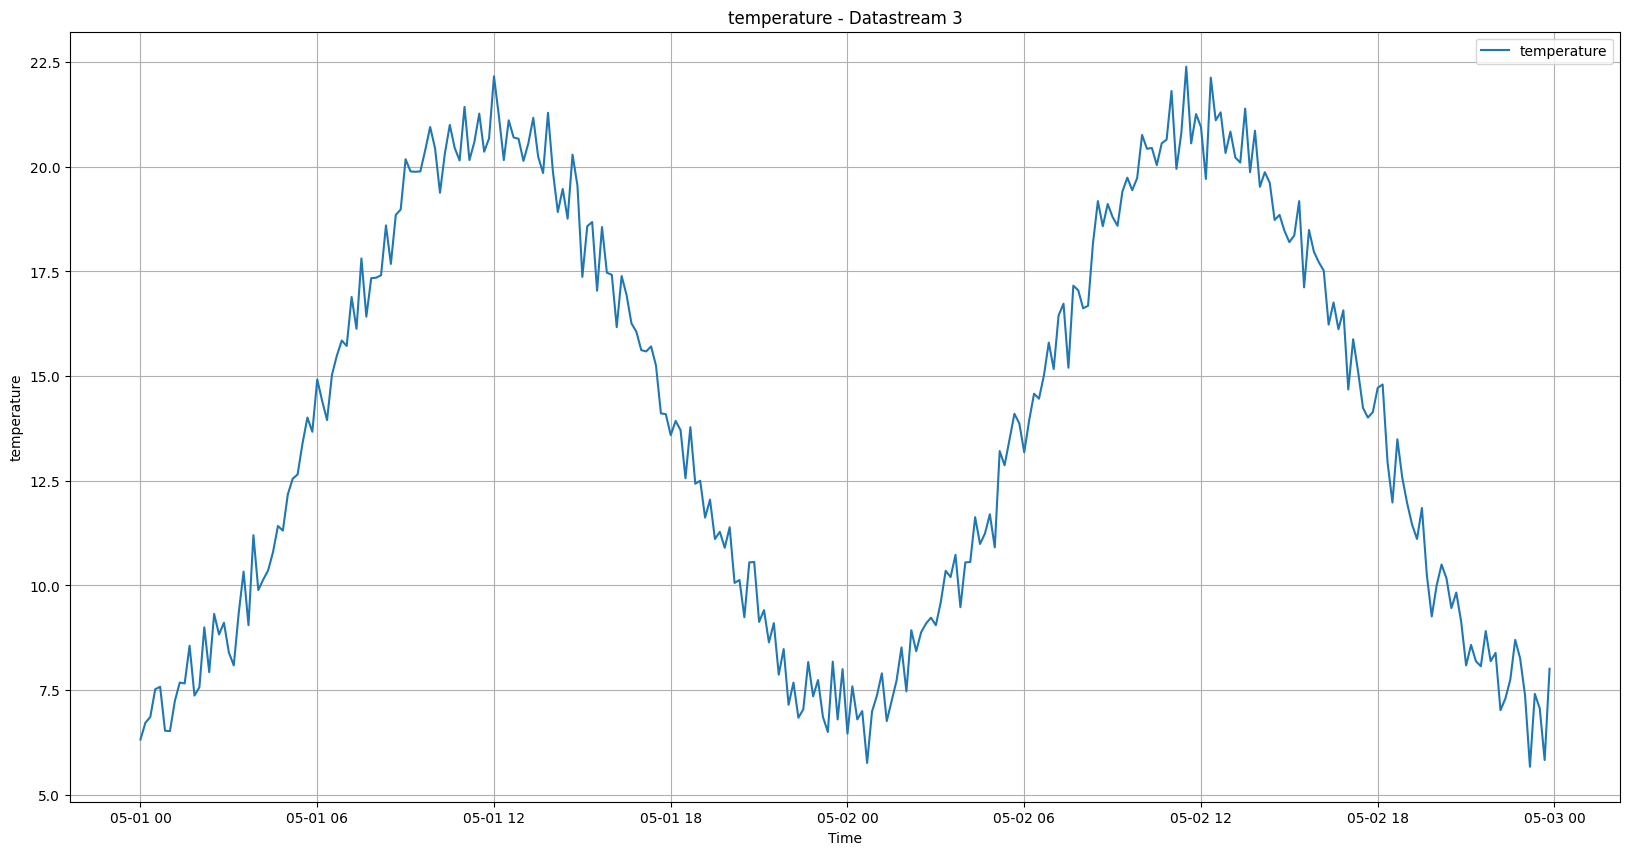

In [16]:
fig, ax = plt.subplots(figsize=(20, 10))

ax.set_title(f"{selected_column} - Datastream {datastream_id}")
ax.set_xlabel("Time")
ax.set_ylabel(selected_column)
ax.grid(True)

ax.plot(dt, values, label=selected_column)
ax.legend()

plt.show()